# SPY real-time GEX: what the live book adds intraday

The daily notebook showed that the sign and level of net GEX at the close describe the next session's range. Open interest only arrives once a day, so a continuous scanner cannot see new positions; what it does is evaluate the previous close's book at the current spot, vol and time: the live book. This notebook measures what that live value is worth on SPY: whether it tracks the next official print, whether it predicts the next half hour better than the stale value, what an intraday crossing of the flip level does to the rest of the day, whether the walls act as intraday levels, and how much the exercise model matters.

## Definitions

- Live GEX at time t: the previous close's solved chain (same open interest, each contract's IV fixed) re-evaluated at spot S_t. Computed from the daily profile on a spot grid from 0.90 S to 1.10 S in 0.25% steps and interpolated. Time decay inside the day is ignored.
- Regime at the prior close: sign of the official net GEX of D-1. Live regime: sign of the live value.
- Buckets: 30 minutes, 13 per session from the traded 1-minute bars. Adjusted range: the bucket's (high - low) / prior close divided by the median for that time of day, which removes the intraday U-shape.
- Flip level: zero crossing of the profile nearest to spot. Walls: strikes with the largest positive and most negative net GEX at the prior close.

In [1]:
import json
import sys
import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, "gex_history")
import gexlib as G
import intraday as I
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
stock, sofr, days = G.load_stock(), G.load_sofr(), G.study_days()
daily = pd.read_csv(G.RESULTS / "spy_gex_daily.csv", parse_dates=["date"]).set_index("date")
chain, shares = G.prep_all(days, stock, sofr, verbose=False)
sol, timings = G.solve_chain(chain, target="cpu", dtype="fp64")
print(f"{len(daily)} days; {timings['n_contracts']:,} contracts solved in {timings['t_iv_s'] + timings['t_greeks_s']:.1f}s on the CPU")

751 days; 2,392,386 contracts solved in 12.0s on the CPU


## The live profile

One profile per day: net GEX of the solved chain at 81 spot points. The live value at any intraday spot is a lookup on it. On the RTX PRO 6000 Blackwell the same 81-point re-evaluation of the whole 2.4M-contract history is a fraction of a second in fp32; here the CPU fp64 build does it in about two minutes for the record.

In [2]:
t0 = time.perf_counter()
prof = I.daily_profiles(sol, verbose=False)
prof.to_parquet(G.CACHE / "spy_profiles.parquet")
print(f"profiles: {prof.shape[0]} days x {prof.shape[1]} spot points in {time.perf_counter() - t0:.0f}s (CPU fp64)")
print(f"largest relative gap between the profile at spot and the daily series: {((prof[1.0].reindex(daily.index) - daily.gex_net_usd).abs() / daily.gex_net_usd.abs()).max():.1e}")

profiles: 751 days x 81 spot points in 103s (CPU fp64)
largest relative gap between the profile at spot and the daily series: 4.9e-08


## The live value against the next official print

At the close of D the scanner holds the D-1 book live at S_D. The next morning's official print uses the new open interest and the new closing quotes. If the live value tracks it, the spot move explains most of the day-to-day change in GEX and the live value carries information the stale print does not.

{
 "n_days": 750,
 "sign_agreement_stale": 0.7946666666666666,
 "sign_agreement_live": 0.9293333333333333,
 "corr_level_stale": 0.7719600283894616,
 "corr_level_live": 0.9631976315952924,
 "mad_stale_bn": 2.474937588,
 "mad_live_bn": 1.0124391808530113,
 "days_sign_changed": 154,
 "live_caught_change": 0.7662337662337663
}


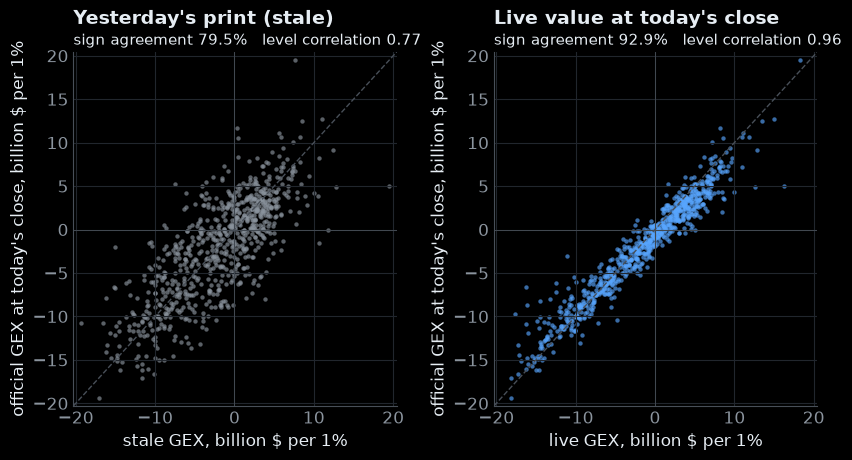

In [3]:
t6 = I.t6_live_tracks_next_print(daily, prof)
print(json.dumps(t6, indent=1))
_ = I.fig_live_versus_stale(daily, prof, t6, G.FIGURES / "f6_live_versus_stale.png")

## The regime inside the day

Per-day realized vol from intraday log returns at 5, 15, 30 and 60 minutes, averaged by the regime at the previous close, with a bootstrap confidence interval of the difference and a Mann-Whitney p-value.

,n_pos,n_neg,rv_pos,rv_neg,median_pos,median_neg,ratio_neg_over_pos,diff,ci_lo,ci_hi,p_mwu
horizon_min,,,,,,,,,,,
5,310,433,0.074,0.118,0.071,0.109,1.58,-0.0431,-0.0512,-0.0358,1.56e-37
15,310,433,0.073,0.117,0.066,0.104,1.61,-0.0445,-0.0535,-0.0366,4.05e-33
30,310,433,0.070,0.115,0.062,0.103,1.64,-0.0450,-0.0533,-0.0374,1.35e-33
60,310,433,0.069,0.111,0.061,0.098,1.63,-0.0429,-0.0513,-0.0350,2.05e-27


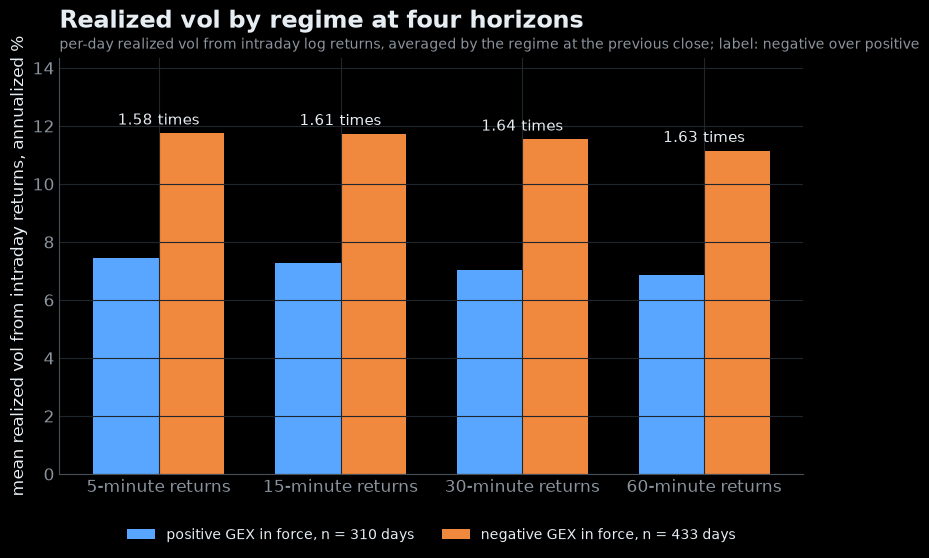

In [4]:
bars = I.load_bars("spy")
t1 = I.t1_intraday_vol(bars, daily)
display(t1.style.format({"rv_pos": "{:.3f}", "rv_neg": "{:.3f}", "median_pos": "{:.3f}", "median_neg": "{:.3f}", "ratio_neg_over_pos": "{:.2f}", "diff": "{:+.4f}", "ci_lo": "{:+.4f}", "ci_hi": "{:+.4f}", "p_mwu": "{:.2e}"}))
_ = I.fig_intraday_vol(t1, G.FIGURES / "f8_intraday_vol.png")

## Live against stale, bucket by bucket

For every 30-minute bucket b: the stale value (prior close), the live value at the bucket close, and the next bucket's adjusted range. Pooled Spearman for each, then a joint rank regression with standard errors clustered by day. The within-day column asks whether the live value's movement inside a day picks out the wide buckets once the day's mean is removed.

In [5]:
ob = I.attach_regime(I.bucketize(bars, 30), daily, prof)
t2 = I.t2_live_versus_stale(ob)
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in t2.items() if k != "flip_vs_same_by_prev_regime"})
pd.DataFrame(t2["flip_vs_same_by_prev_regime"]).T.style.format("{:.3f}")

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


{'n_buckets': 8916, 'n_days': 743, 'spearman_stale': -0.429, 'spearman_live': -0.518, 'spearman_increment_within_day': -0.033, 'share_buckets_flipped': 0.16, 'share_days_with_any_flip': 0.287}


,n_flipped,n_same,next_range_adj_flipped,next_range_adj_same,diff,ci_lo,ci_hi,p_mwu
prev_negative,847.000,4349.000,0.964,1.586,-0.622,-0.682,-0.562,0.000
prev_positive,581.000,3139.000,1.188,0.890,0.298,0.240,0.358,0.000


## Intraday flips

29% of days see the live sign leave the prior close's sign at some point. The event study lines up buckets on the first crossing. The control restricts to days that started within 0.5% of the flip, where the stale print alone already places spot near the boundary, and compares the rest of the day on days that crossed against days that did not.

share of days with an intraday flip: 0.291 | first flip bucket counts: {0.0: 100, 1.0: 22, 2.0: 16, 3.0: 11, 4.0: 14, 5.0: 8, 6.0: 9, 7.0: 5, 8.0: 7, 9.0: 7, 10.0: 4, 11.0: 10, 12.0: 3}
matched on move size: {'neg_to_pos': (-0.638, 117), 'pos_to_neg': (0.313, 86)}
joint regression: {'coef_stale': -0.187, 't_stale': -1.483, 'coef_live': -1.207, 't_live': -10.594, 'r2': 0.139, 'n': 8916, 'se_clustered_by_day': True}


,n_cross,n_stay,median_flip_bucket,post_range_adj_cross,post_range_adj_stay,diff,ci_lo,ci_hi,p_mwu
neg_to_pos,74.000,60.000,0.000,0.969,1.236,-0.267,-0.401,-0.133,0.000
pos_to_neg,71.000,102.000,0.000,1.122,0.814,0.308,0.211,0.404,0.000


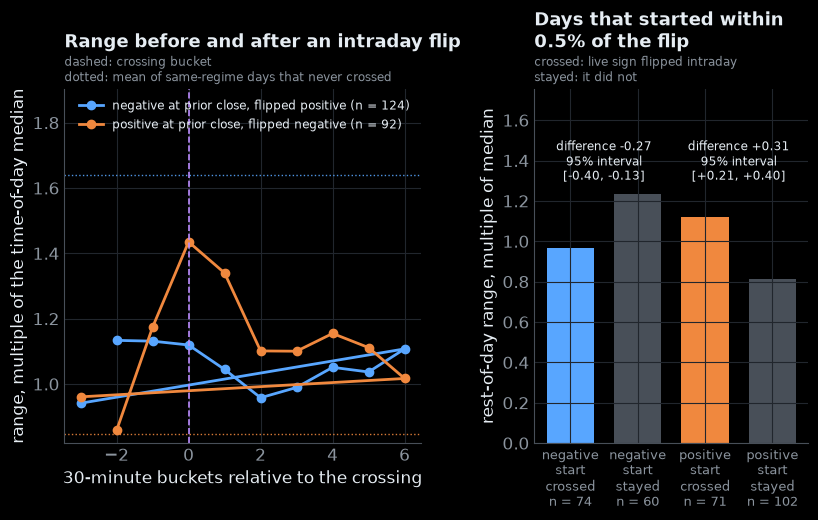

In [6]:
t3, flipdays = I.t3_intraday_flips(ob)
t3b = I.t3b_near_flip(ob, flipdays, near_pct=0.5)
t3b_1 = I.t3b_near_flip(ob, flipdays, near_pct=1.0)
print("share of days with an intraday flip:", round(t3["share_days_flipped"], 3), "| first flip bucket counts:", t3["flip_bucket_distribution"])
print("matched on move size:", {k: (round(v["post_flip_minus_reference_matched"], 3), v["n_flip_days"]) for k, v in t3["by_direction"].items()})
print("joint regression:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in t3b["joint_regression"].items()})
display(pd.DataFrame(t3b["near_flip_cross_vs_stay"]).T.style.format("{:.3f}"))
_ = I.fig_intraday_flip(ob, flipdays, t3b, G.FIGURES / "f7_intraday_flip.png")

## Walls as intraday levels

First intraday touch of the prior close's call wall from below and put wall from above, within 5 basis points. Signed return over the next 30 and 60 minutes, against the same measurement on placebo levels 5 dollars above and below the wall. The result is reported either way.

{
 "call": {
  "n_days_wall_beyond_spot": 695,
  "touch_rate": 0.1856115107913669,
  "touch_rate_by_prev_regime": {
   "-1.0": 0.098,
   "1.0": 0.328
  },
  "after_touch_30m_bp_mean": -1.16211727896191,
  "after_touch_30m_share_reversal": 0.5409836065573771,
  "n_touch_30m": 122,
  "after_touch_30m_ci": [
   -3.865817329177822,
   1.5134163434448265
  ],
  "after_touch_60m_bp_mean": -1.3547227518022502,
  "after_touch_60m_share_reversal": 0.5254237288135594,
  "n_touch_60m": 118,
  "after_touch_60m_ci": [
   -5.316281861646103,
   2.5681956830802157
  ]
 },
 "put": {
  "n_days_wall_beyond_spot": 699,
  "touch_rate": 0.12875536480686695,
  "touch_rate_by_prev_regime": {
   "-1.0": 0.216,
   "1.0": 0.022
  },
  "after_touch_30m_bp_mean": -2.6725692664617435,
  "after_touch_30m_share_reversal": 0.45348837209302323,
  "n_touch_30m": 86,
  "after_touch_30m_ci": [
   -8.583124185188488,
   3.157487492478275
  ],
  "after_touch_60m_bp_mean": -4.463700261047835,
  "after_touch_60m_share_revers

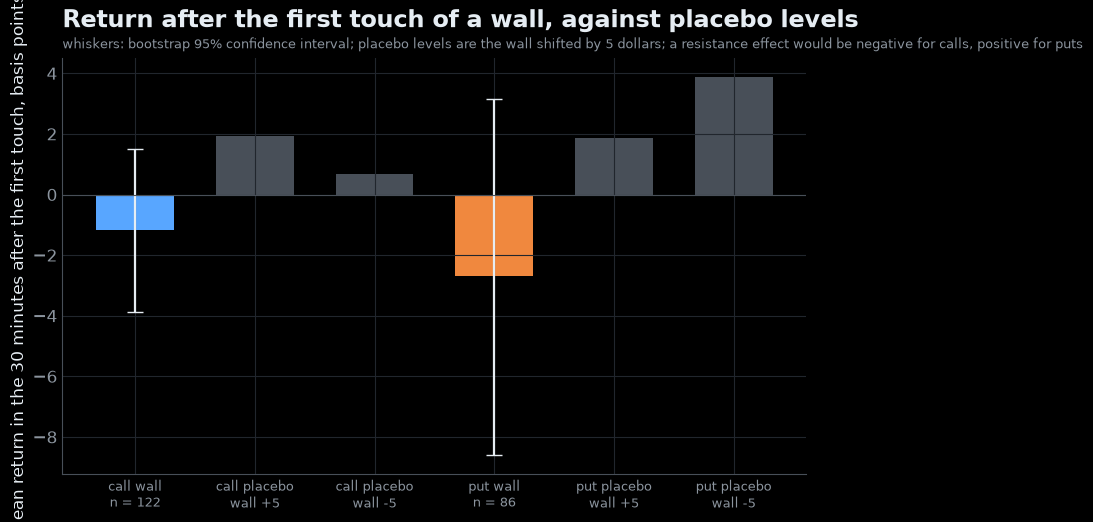

In [7]:
t4 = I.t4_wall_touches(bars, daily)
print(json.dumps({s: {k: v for k, v in t4[s].items() if k != "placebo"} for s in ("call", "put")}, indent=1))
print("inside both walls all day:", round(t4["day_inside_both_walls_share"], 3), t4["day_inside_both_walls_by_prev_regime"])
_ = I.fig_wall_touches(t4, G.FIGURES / "f10_wall_touches.png")

## Time of day

,neg,pos,ratio_neg_over_pos
bucket,,,
0,0.445,0.274,1.620
1,0.425,0.251,1.694
2,0.353,0.223,1.579
3,0.325,0.197,1.650
4,0.294,0.182,1.614
5,0.271,0.175,1.553
6,0.276,0.163,1.692
7,0.299,0.172,1.741
8,0.266,0.164,1.621


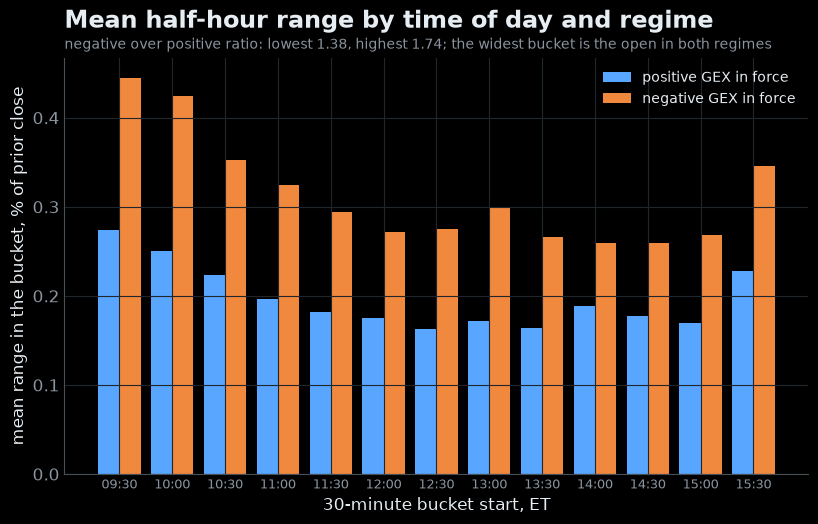

In [8]:
t5 = I.t5_time_of_day(ob)
display(t5.style.format("{:.3f}"))
_ = I.fig_time_of_day(t5, G.FIGURES / "f9_time_of_day.png")

## The 0DTE layer

Contracts expiring on day D are gone at the close and never enter the daily print, yet they are alive all session. Their open interest is in the open interest file dated D (positions as of the D-1 close, the freshest available during D), their IV comes from the D-1 solve of the same contracts, and gamma is evaluated at every bucket close with the true remaining time. Positions opened during D are invisible, so this layer is a lower bound. Tests: its size against the standing book by time of day, whether its magnitude adds to the next-bucket range prediction, and the 15:30 to 16:00 range against the 0DTE exposure at 15:30, with the day's own range so far as a control.

743 days, median 68 same-day contracts within 3% of the prior close, 74s
Spearman with the next bucket's range: {'stale': -0.429, 'live': -0.518, 'live_plus_0dte_signed': -0.514, 'unsigned_0dte_alone': -0.294, 'signed_0dte_alone': -0.36}
joint regression t-statistics (next bucket): {'live_rank': -13.0, 'u0dte_rank': -5.4, 's0dte_rank': 0.2}
last half hour, controlled for range so far and regime, t-statistics: {'u0dte_rank': -2.4, 'range_sofar_rank': 11.0, 'book_rank': -2.2, 'prev_negative': -0.9}
same-day-expiry open interest on D over D-1: {'n_days': 750, 'median_ratio_D_over_Dminus1': 1.9, 'p25': 1.54, 'p75': 2.15}


,ugex_0dte_bn,book_abs_bn,share_0dte,net_0dte_positive_share
bucket,,,,
0,5.600,4.202,0.598,0.598
1,5.608,4.229,0.591,0.579
2,5.464,4.374,0.583,0.573
3,5.487,4.346,0.586,0.580
4,5.431,4.409,0.586,0.600
5,5.403,4.508,0.578,0.590
6,5.423,4.514,0.572,0.579
7,5.359,4.490,0.566,0.592
8,5.418,4.525,0.565,0.583


,n,last_half_hour_range_adj_low_0dte,high_0dte,diff_high_minus_low,ci_lo,ci_hi,p_mwu,spearman_ugex_vs_last_range,spearman_signed_vs_last_range
prev_positive,310.000,1.118,0.877,-0.241,-0.418,-0.078,0.001,-0.226,-0.316
prev_negative,433.000,1.834,1.296,-0.538,-0.820,-0.256,0.000,-0.264,-0.350
all,743.000,1.595,1.073,-0.522,-0.699,-0.341,0.000,-0.306,-0.370


,n,low_0dte,high_0dte,diff,ci_lo,ci_hi
narrow so far,248.000,0.847,0.708,-0.138,-0.248,-0.038
middle,247.000,1.267,1.140,-0.128,-0.317,0.061
wide so far,248.000,2.249,1.668,-0.581,-1.003,-0.162


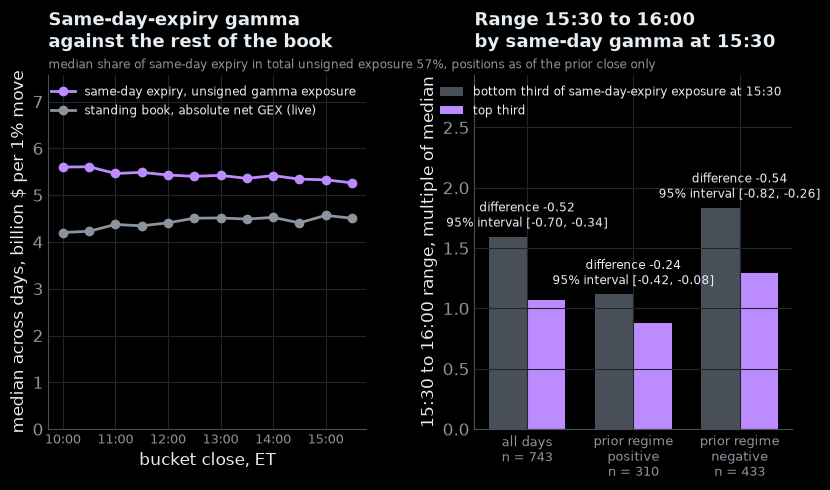

In [9]:
t0 = time.perf_counter()
layer = I.zero_dte_layer(sol, daily, ob)
t8 = I.t8_zero_dte(layer); t8c = I.t8_controls(layer, sol, daily)
print(f"{t8['n_days']} days, median {t8['median_contracts_per_day']:.0f} same-day contracts within 3% of the prior close, {time.perf_counter() - t0:.0f}s")
print("Spearman with the next bucket's range:", {k: round(v, 3) for k, v in t8["spearman_next_range"].items()})
print("joint regression t-statistics (next bucket):", {k: round(v, 1) for k, v in t8["joint_regression_t"].items()})
print("last half hour, controlled for range so far and regime, t-statistics:", {k: round(v, 1) for k, v in t8c["last_half_hour_controlled_t"].items()})
print("same-day-expiry open interest on D over D-1:", {k: round(v, 2) for k, v in t8c["same_day_expiry_oi_growth_on_last_day"].items()})
display(pd.DataFrame(t8["by_bucket"]).set_index("bucket").style.format("{:.3f}"))
display(pd.DataFrame(t8["last_half_hour_by_0dte_exposure_at_1530"]).T.style.format("{:.3f}"))
display(pd.DataFrame(t8c["last_half_hour_within_day_vol_strata"]).T.style.format("{:.3f}"))
_ = I.fig_zero_dte(t8, G.FIGURES / "f14_zero_dte.png")

## The exercise model's effect

The same chain solved with European exercise (Black-Scholes-Merton) instead of the American engine: daily sign agreement, median absolute difference in net GEX, and the gamma ratio by moneyness.

In [10]:
t7 = I.t7_model_choice(sol, daily)
print(json.dumps(t7, indent=1))
res = {"symbol": "SPY", "buckets_minutes": 30, "T1_intraday_vol_by_regime": t1.reset_index().to_dict("records"), "T2_live_versus_stale": t2,
       "T3_intraday_flips": t3, "T3b_near_flip_control_0.5pct": t3b, "T3b_near_flip_control_1pct": t3b_1, "T4_wall_touches": t4,
       "T5_time_of_day_range_pct": t5.reset_index().to_dict("records"), "T6_live_tracks_next_print": t6, "T7_model_choice_american_vs_european": t7,
       "T8_zero_dte_layer": t8, "T8b_zero_dte_controls": t8c}
G.save_json(res, G.RESULTS / "intraday_spy.json")

{
 "n_contracts": 2352505,
 "european_iv_unsolved_share": 0.0,
 "t_iv_european_s": 1.77,
 "sign_agreement_daily": 0.9800266311584553,
 "days_sign_differs": 15,
 "median_abs_diff_bn": 0.25749985288619043,
 "median_rel_gamma_american_over_european": 1.000000000000956,
 "p10_p90_rel_gamma": [
  0.9999999999999934,
  1.0399479568736425
 ],
 "put_itm_median_ratio": 1.0668331941569726,
 "call_itm_median_ratio": 1.0000000000000002,
 "otm_median_ratio": 1.001011370607351
}


## Conclusions

1. The live book tracks the next official print: sign agreement with the next day's GEX 92.9% against 79.5% for the stale value, level correlation 0.96 against 0.77; of the 154 days on which the sign changed, the live value caught 77% by the close.
2. Realized vol by regime at intraday horizons: under negative GEX it is 1.58 times the positive-regime value from 5-minute returns and 1.63 times from 60-minute returns, p-value below 0.001 at each horizon.
3. The live value predicts the next half hour better than the stale print: Spearman with the next bucket's adjusted range -0.52 against -0.43; in a joint rank regression the live value carries a t-statistic of -10.6 and the stale value -1.5. Within a day the live value's movement does not pick out individual buckets (within-day Spearman -0.03); what it adds is an updated level for the day.
4. Intraday flips: the live sign differs from the prior close on 29% of days. Among days that started within 0.5% of the flip, crossing up from a negative start cut the rest-of-day range to 0.97 times the time-of-day median against 1.24 times when it stayed (confidence interval [-0.40, -0.13]); crossing down from a positive start raised it to 1.12 times against 0.81 times (confidence interval [+0.21, +0.40]).
5. Walls as intraday levels: the mean 30-minute return after the first touch is -1.2 basis points for the call wall (confidence interval [-3.9, +1.5], n = 122) and -2.7 basis points for the put wall (confidence interval [-8.6, +3.2], n = 86), indistinguishable from the placebo levels.
6. Model choice: solving the same chain as European instead of American changes the daily sign on 15 of 751 days and moves net GEX by a median 0.26 billion dollars; American gamma is 1.067 times the European value for in-the-money puts and equal for calls.
7. The 0DTE layer: same-day-expiry contracts carry a median 5.6 billion dollars of unsigned gamma exposure at 10:00 against 4.2 billion for the whole standing book, 60% of the total, from positions as of the prior close alone, and that open interest roughly doubles on the last day before expiry (median ratio 1.90). Its magnitude damps the next half hour beyond the live book (joint regression t-statistic -5.4 against -13.0 for the book; its sign adds nothing, t-statistic 0.2). At 15:30 the top third of 0DTE exposure is followed by a 15:30 to 16:00 range of 1.07 times the time-of-day median against 1.59 for the bottom third (95% confidence interval of the difference [-0.70, -0.34]); controlling for the day's range so far the effect shrinks to a t-statistic of -2.4, holding in the narrow and wide thirds of days (confidence intervals [-0.25, -0.04] and [-1.00, -0.16]) and not in the middle third.

Educational analysis, not a trading strategy.